In [1]:
!pip install matplotlib scikit-learn transformers

# Connecting to google drive to load the data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Organising data into train and test folders

In [3]:

import os
import shutil
import random

base_dir = "/content/drive/MyDrive/dataset"
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")

split_ratio = 0.8
random.seed(42)


os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)


In [4]:
classes = [
    d for d in os.listdir(base_dir)
    if os.path.isdir(os.path.join(base_dir, d))
    and d not in ["train", "val"]
]

for cls in classes:
    cls_path = os.path.join(base_dir, cls)
    images = [f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))]

    random.shuffle(images)
    split_idx = int(len(images) * split_ratio)

    train_images = images[:split_idx]
    val_images   = images[split_idx:]

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

    for img in train_images:
        src = os.path.join(cls_path, img)
        dst = os.path.join(train_dir, cls, img)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)

    for img in val_images:
        src = os.path.join(cls_path, img)
        dst = os.path.join(val_dir, cls, img)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)

print("✅ Dataset split completed safely.")

✅ Dataset split completed safely.


# Importing necessary libraries

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torchvision import models
from tqdm import tqdm
from torchvision import models
import torch.nn as nn
import matplotlib.pyplot as plt
import random
import json
import os
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from transformers import get_cosine_schedule_with_warmup
from transformers import DeiTForImageClassification, DeiTImageProcessor
import os

# Loading the porcessor

In [6]:
model_name = "facebook/deit-base-distilled-patch16-224"
processor = DeiTImageProcessor.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

# Custom dataloader class and transforms

In [ ]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomRotation(10),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3)
    ], p=0.2),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224))
])

In [8]:
class Car_damage_dataset(Dataset):
    def __init__(self, data_dir, processor, transform=None):
        self.dataset = ImageFolder(root=data_dir, transform=transform)
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]

        enc = self.processor(
            images=image,
            return_tensors='pt'
        )

        return {
            'pixel_values': enc['pixel_values'].squeeze(0),
            'labels': torch.tensor(label)
        }

In [9]:
train_path = "/content/drive/MyDrive/dataset/train"
test_path   = "/content/drive/MyDrive/dataset/val"


train_dataset = Car_damage_dataset(data_dir=train_path, transform=train_transforms, processor=processor)

test_dataset  = Car_damage_dataset(data_dir=test_path, transform=val_transforms, processor=processor)

In [10]:
class_to_idx = train_dataset.dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
idx_to_class

{0: 'F_Breakage',
 1: 'F_Crushed',
 2: 'F_Normal',
 3: 'R_Breakage',
 4: 'R_Crushed',
 5: 'R_Normal'}

# Visualising the train test split

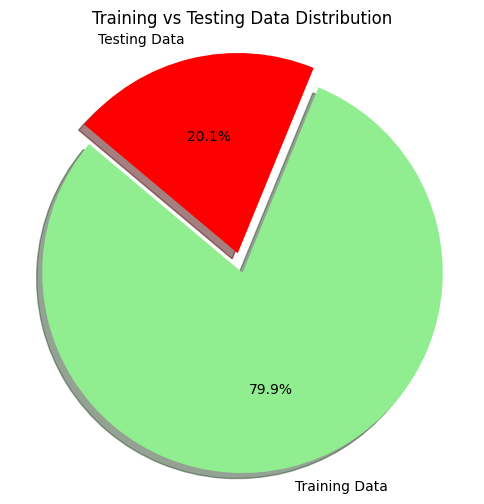

In [11]:
labels = ['Training Data', 'Testing Data']
sizes  = [len(train_dataset), len(test_dataset)]
colors = ['lightgreen', 'red']
explode = (0.1, 0)
plt.figure(figsize=(6, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Training vs Testing Data Distribution')
plt.axis('equal')
plt.show()

# Ploting the image distribution across the classes

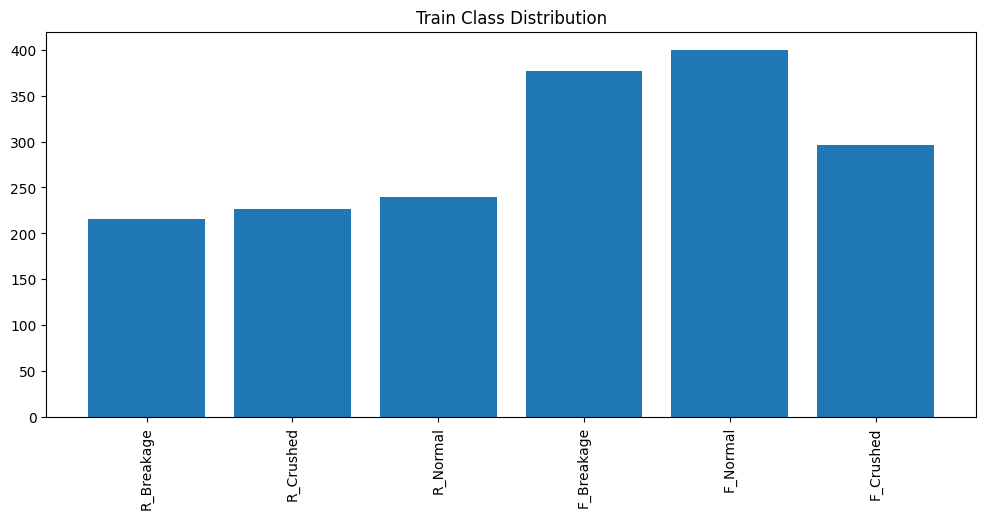

In [12]:
def plot_class_distribution(data_path):
    classes = os.listdir(data_path)
    counts = []

    for cls in classes:
        cls_path = os.path.join(data_path, cls)
        if os.path.isdir(cls_path):
            counts.append(len(os.listdir(cls_path)))

    plt.figure(figsize=(12,5))
    plt.bar(classes, counts)
    plt.xticks(rotation=90)
    plt.title("Train Class Distribution")
    plt.show()

plot_class_distribution("/content/drive/MyDrive/dataset/train")

In [13]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=10, pin_memory=True, persistent_workers=True)

eval_loader = DataLoader(test_dataset, batch_size=128, num_workers=10, pin_memory=True, persistent_workers=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 10 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Initializing the model


In [ ]:
model = DeiTForImageClassification.from_pretrained(
    model_name,
    num_labels=6,
    ignore_mismatched_sizes=True
)

for param in model.deit.parameters():
    param.requires_grad = False

for param in model.deit.encoder.layer[-4:].parameters():
    param.requires_grad = True

for param in model.deit.layernorm.parameters():
    param.requires_grad = True

model.to(device)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/349M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/349M [00:00<?, ?B/s]

DeiTForImageClassification LOAD REPORT from: facebook/deit-base-distilled-patch16-224
Key                            | Status     | 
-------------------------------+------------+-
distillation_classifier.bias   | UNEXPECTED | 
distillation_classifier.weight | UNEXPECTED | 
cls_classifier.weight          | UNEXPECTED | 
cls_classifier.bias            | UNEXPECTED | 
classifier.weight              | MISSING    | 
classifier.bias                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DeiTForImageClassification(
  (deit): DeiTModel(
    (embeddings): DeiTEmbeddings(
      (patch_embeddings): DeiTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): DeiTEncoder(
      (layer): ModuleList(
        (0-11): 12 x DeiTLayer(
          (attention): DeiTAttention(
            (attention): DeiTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): DeiTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): DeiTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
          

# Code for early stopping

In [16]:
class EarlyStopping:
    def __init__(self, patience=6, min_delta=0.0005):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, metric):
        if self.best_score is None:
            self.best_score = metric
        elif metric < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = metric
            self.counter = 0

# Critetion and optimizer
- Uing different LR for classifier and last trainable layers

In [17]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW([
    {"params": model.deit.encoder.layer[-4:].parameters(), "lr": 3e-5},
    {"params": model.deit.layernorm.parameters(), "lr": 3e-5},
    {"params": model.classifier.parameters(), "lr": 1e-4}
], weight_decay=1e-4)

# Training Function

In [18]:
def train_model(
    model,
    epochs,
    train_loader,
    eval_loader,
    optimizer,
    criterion,
    device,
    patience=6,
    checkpoint_model_name="model"
):

    print("Starting training...")
    print(f"Epochs: {epochs} | Device: {device}")
    print("-" * 60)

    # ------------------------- SCHEDULER -------------------------
    num_training_steps = epochs * len(train_loader)
    num_warmup_steps = int(0.1 * num_training_steps)

    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps
    )

    early_stopping = EarlyStopping(patience=patience)

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    best_acc = 0.0

    # ------------------------- TRAIN LOOP -------------------------
    for epoch in range(epochs):

        # --------------------- TRAIN ---------------------
        model.train()
        running_loss, correct, total = 0, 0, 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):

            images = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad(set_to_none=True)

            outputs = model(images)
            logits = outputs.logits

            loss = criterion(logits, labels)
            loss.backward()

            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            preds = torch.argmax(logits, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # --------------------- VALIDATION ---------------------
        model.eval()
        val_running_loss, val_correct, val_total = 0, 0, 0

        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in tqdm(eval_loader, desc=f"Epoch {epoch+1} Validation"):

                images = batch['pixel_values'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(images)
                logits = outputs.logits

                loss = criterion(logits, labels)

                val_running_loss += loss.item()

                preds = torch.argmax(logits, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = val_running_loss / len(eval_loader)
        val_acc = 100 * val_correct / val_total

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(
            f"Results "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% || "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
        )
        print("-" * 60)

        # --------------------- SAVE BEST MODEL (BY ACCURACY) ---------------------
        if val_acc > best_acc:
            best_acc = val_acc

            os.makedirs("checkpoints", exist_ok=True)

            torch.save({
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch,
                "val_acc": val_acc
            }, f"checkpoints/{checkpoint_model_name}.pt")

            print(f"Best model saved (Acc: {val_acc:.2f}%)")

        # --------------------- EARLY STOPPING ---------------------
        early_stopping(val_acc)

        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch+1}")
            break

    return (
        train_losses,
        train_accs,
        val_losses,
        val_accs,
        all_preds,
        all_labels
    )

# Training the model

In [19]:
train_losses, train_accuracy, eval_losses, eval_accuracies, all_preds, all_labels = train_model(model=model,
                                           epochs=100,
                                           train_loader=train_loader,
                                           eval_loader=eval_loader,
                                           optimizer=optimizer,
                                           criterion=criterion,
                                           patience=6,
                                           device=device,
                                           checkpoint_model_name='best_deit_model')


Starting training...
Epochs: 100 | Device: cuda
------------------------------------------------------------



Epoch 1 Training:   0%|          | 0/14 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 10 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

Epoch 1 Validation: 100%|██████████| 4/4 [00:38<00:00,  9.62s/it]


Results Train Loss: 1.8422 | Train Acc: 19.77% || Val Loss: 1.8379 | Val Acc: 21.32%
------------------------------------------------------------
Best model saved (Acc: 21.32%)


Epoch 2 Validation: 100%|██████████| 4/4 [00:13<00:00,  3.27s/it]


Results Train Loss: 1.7477 | Train Acc: 26.21% || Val Loss: 1.6967 | Val Acc: 30.39%
------------------------------------------------------------
Best model saved (Acc: 30.39%)


...

Results Train Loss: 0.5483 | Train Acc: 96.75% || Val Loss: 0.8233 | Val Acc: 79.82%
------------------------------------------------------------


Epoch 20 Validation: 100%|██████████| 4/4 [00:11<00:00,  2.90s/it]


Results Train Loss: 0.5301 | Train Acc: 97.55% || Val Loss: 0.8255 | Val Acc: 79.14%
------------------------------------------------------------


Epoch 21 Validation: 100%|██████████| 4/4 [00:11<00:00,  2.82s/it]

Results Train Loss: 0.5188 | Train Acc: 98.63% || Val Loss: 0.8077 | Val Acc: 80.73%
------------------------------------------------------------
Early stopping at epoch 21


# Plotting the loss and accuracy

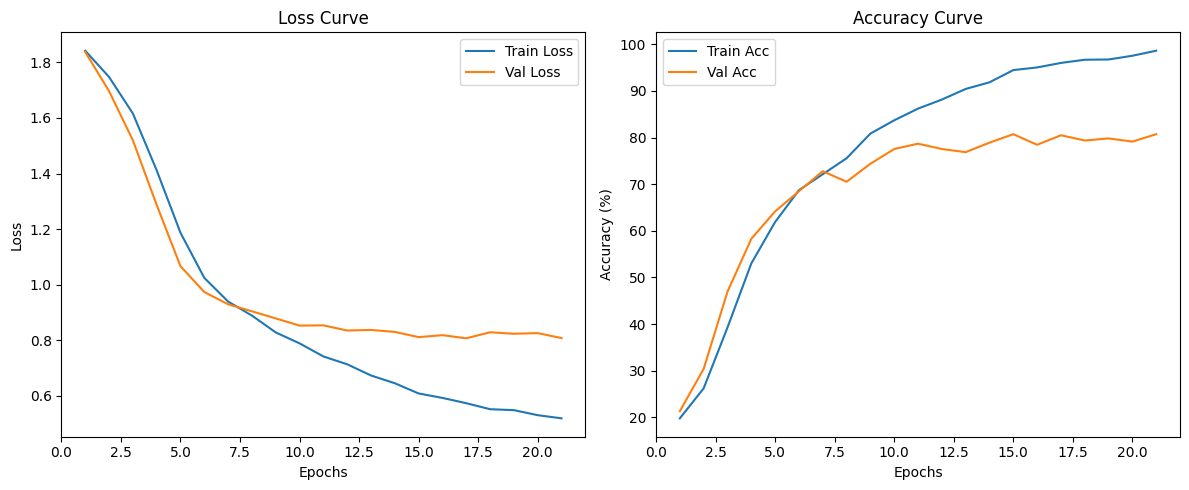

In [20]:
def plot_training_curves(train_losses, eval_losses, train_acc, eval_acc):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, eval_losses, label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, train_acc, label="Train Acc")
    plt.plot(epochs, eval_acc, label="Val Acc")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy Curve")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_curves(
    train_losses,
    eval_losses,
    train_accuracy,
    eval_accuracies
)

# Plotting Confusion Matrix

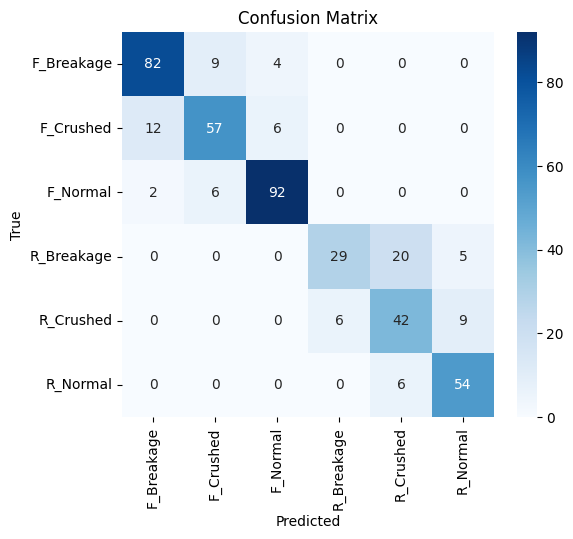

In [21]:
def plot_confusion_matrix_normalized(all_labels, all_preds):
  class_names = train_dataset.dataset.classes
  cm = confusion_matrix(all_labels, all_preds)
  plt.figure(figsize=(6, 5))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.title("Confusion Matrix")
  plt.show()

plot_confusion_matrix_normalized(all_labels, all_preds)

# Classification Report

In [22]:
def print_classification_report(all_labels, all_preds, class_names=None):
    class_names = train_dataset.dataset.classes
    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
    print(report)
print_classification_report(all_labels, all_preds)

              precision    recall  f1-score   support

  F_Breakage       0.85      0.86      0.86        95
   F_Crushed       0.79      0.76      0.78        75
    F_Normal       0.90      0.92      0.91       100
  R_Breakage       0.83      0.54      0.65        54
   R_Crushed       0.62      0.74      0.67        57
    R_Normal       0.79      0.90      0.84        60

    accuracy                           0.81       441
   macro avg       0.80      0.79      0.79       441
weighted avg       0.81      0.81      0.80       441

